# XGBoost trên ViCTSD

So sánh XGBoost + TF-IDF trên nhãn gốc và nhãn AI re-annotated.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Run this notebook from the project root or notebooks/ directory.')

sys.path.insert(0, str(PROJECT_ROOT))
root = PROJECT_ROOT
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/abc/Documents/multi-agent-annotation


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.experiment_utils import (
    compare_predictions,
    compare_prediction_disagreements,
    evaluate_predictions,
    load_victsd_splits,
    make_text_xy,
    train_predict_pair,
)

sns.set_theme(style='whitegrid')

In [3]:
splits = load_victsd_splits(root / 'data')

X_train_orig, y_train_orig = make_text_xy(splits['train_orig'])
X_train_new, y_train_new = make_text_xy(splits['train_new'])
X_test, y_test = make_text_xy(splits['test'])

Loaded splits: train_orig=7000, train_new=7000, valid_orig=2000, valid_new=2000, test=1000


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

MODEL_NAME = 'XGBoost'

def build_model():
    return Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)),
        ('clf', XGBClassifier(
            eval_metric='logloss',
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
        )),
    ])

Training XGBoost on original labels...


--- XGBoost (Original labels) ---
Accuracy=0.8080 | F1 macro=0.7855 | Precision macro=0.7992 | Recall macro=0.7774
                  precision    recall  f1-score   support

Non-constructive       0.82      0.89      0.85       636
    Constructive       0.78      0.66      0.72       364

        accuracy                           0.81      1000
       macro avg       0.80      0.78      0.79      1000
    weighted avg       0.81      0.81      0.80      1000


Training XGBoost on AI re-annotated labels...


--- XGBoost (AI re-annotated labels) ---
Accuracy=0.7430 | F1 macro=0.6640 | Precision macro=0.7888 | Recall macro=0.6599
                  precision    recall  f1-score   support

Non-constructive       0.72      0.97      0.83       636
    Constructive       0.85      0.35      0.50       364

        accuracy                           0.74      1000
       macro avg       0.79      0.66      0.66      1000
    weighted avg       0.77      0.74      0.71      1000


Compare result: XGBoost


,Metric,Original labels,AI re-annotated labels,Delta
0,Accuracy,0.8080,0.7430,-0.0650
1,F1 weighted,0.8044,0.7083,-0.0961
2,F1 macro,0.7855,0.6640,-0.1215
3,Precision macro,0.7992,0.7888,-0.0104
4,Recall macro,0.7774,0.6599,-0.1175


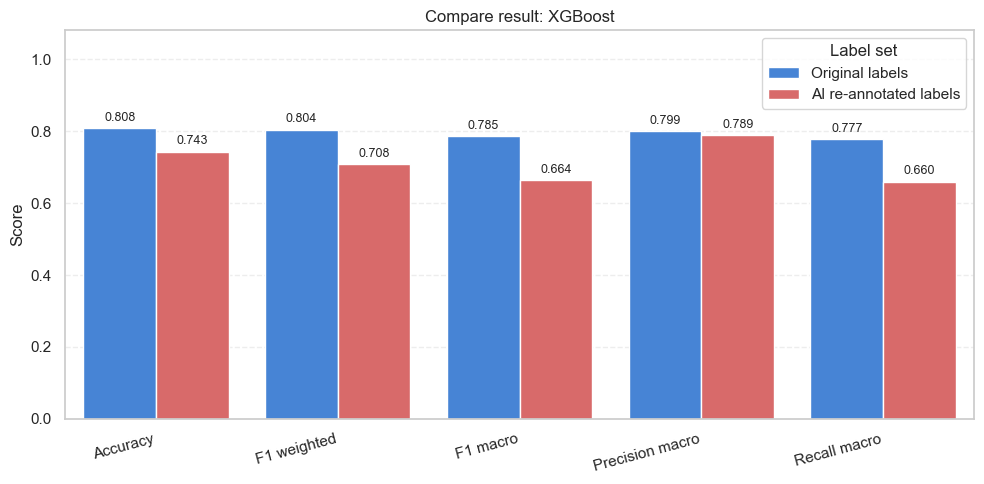

In [5]:
xgb_orig, xgb_new, y_pred_orig, y_pred_new, comparison = train_predict_pair(
    build_model=build_model,
    X_train_original=X_train_orig,
    y_train_original=y_train_orig,
    X_train_reannotated=X_train_new,
    y_train_reannotated=y_train_new,
    X_test=X_test,
    y_test=y_test,
    model_name=MODEL_NAME,
)

In [6]:
diff_df = compare_prediction_disagreements(X_test, y_test, y_pred_orig, y_pred_new)
diff_df.head(10)

Prediction disagreements: 167 / 1000


,text,true_label,pred_original,pred_reannotated
0,đời ta ba mươi đời nó. mua chiếc xe cũng chỉ p...,0,1,0
1,"""một cô giáo đang dạy âm nhạc ở lớp bên cạnh n...",1,1,0
2,"phải sống chung với dịch thôi, đóng đến bao gi...",0,1,0
3,murray cố nhưng cũng k thể thi đấu đỉnh cao đc...,0,1,0
4,nói xin lỗi chứ chắc năm nay đ/c không có con ...,0,0,1
5,"ông này cực kỳ có duyên với cup. ronaldo, kaka...",1,1,0
6,"chào khán giả, thật ra mình cũng xem phim anh ...",1,1,0
7,với giá con luxury mà trang bị như thế em thì ...,1,1,0
8,thời gian vừa qua rất nhiều người nói là nhân ...,1,1,0
9,tôi mua căn hộ quận 9 3 năm nay mà vẫn dài cổ ...,0,1,0
